# 03. 翻訳段を足す — sRNA 制御はタンパク質出力にどう伝わるか

02 の sRNA サイレンシング回路（`m+s→∅` の化学量論的共分解）に、下流の翻訳を追加する。

| 追加反応 | 速度 | 意味 |
|---|---|---|
| $m \to m + P$ | $k_p$ | 翻訳（mRNA は触媒として残る） |
| $P \to \varnothing$ | $b_p$ | タンパク質分解 |

**問い**: mRNA レベルのゆらぎは、最終産物のタンパク質でどうなるか?
タンパク質を mRNA より長寿命 ($b_p < b_m$) にすると、時間平均（低域通過フィルタ）でノイズは均されるはず。
でも 02 で見た「閾値近傍のノイズ増幅」は消えるのか、伝わるのか?

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from ecell4 import run_simulation
from ecell4_base.core import NetworkModel, ReactionRule, Species

M, S, PROT = Species('m'), Species('s'), Species('P')
A_M, B_M, B_S, K = 10.0, 1.0, 1.0, 100.0
K_P, B_P = 5.0, 0.5   # 翻訳速度 / タンパク質分解 (b_p < b_m: P は長寿命)

def build_model(a_s):
    mdl = NetworkModel()
    for rr in [ReactionRule([], [M], A_M), ReactionRule([], [S], a_s),
               ReactionRule([M], [], B_M), ReactionRule([S], [], B_S),
               ReactionRule([M, S], [], K),
               ReactionRule([M], [M, PROT], K_P),   # m -> m + P
               ReactionRule([PROT], [], B_P)]:      # P -> ∅
        mdl.add_reaction_rule(rr)
    return mdl

In [2]:
def ode_steady(a_s):
    r = run_simulation(150.0, y0={'m':0,'s':0,'P':0}, model=build_model(a_s),
                       solver='ode', ndiv=1500, species_list=['m','s','P'])
    m, _, p = r.as_array()[-1][1:4]; return m, p

def gillespie_cv(a_s, t_end=600.0, ndiv=6000, burn=0.25, seed=0):
    r = run_simulation(t_end, y0={'m':0,'s':0,'P':0}, model=build_model(a_s),
                       solver='gillespie', ndiv=ndiv, species_list=['m','s','P'], rndseed=seed)
    tail = r.as_array()[int(ndiv*burn):]
    cv = lambda x: x.std()/x.mean() if x.mean() > 0.3 else np.nan
    return cv(tail[:,1]), cv(tail[:,3])   # CV_m, CV_P

a_grid = np.array([0,2,4,6,8,9,10,11,12,14,16], dtype=float)
m_ode, p_ode = np.array([ode_steady(a) for a in a_grid]).T
cv_m, cv_p = np.array([gillespie_cv(a) for a in a_grid]).T

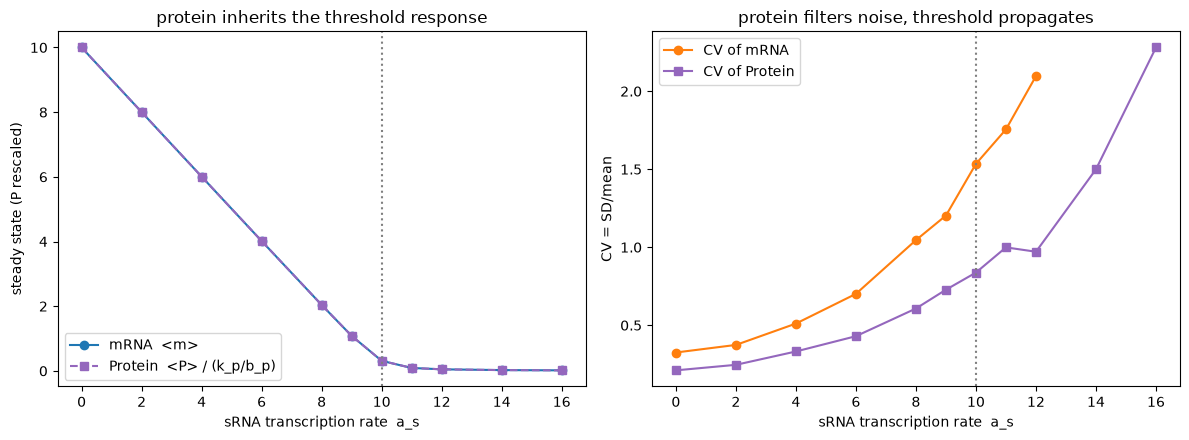

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(a_grid, m_ode, 'o-', color='C0', label='mRNA  <m>')
ax1.plot(a_grid, p_ode/(K_P/B_P), 's--', color='C4', label='Protein  <P> / (k_p/b_p)')
ax1.axvline(A_M, ls=':', c='gray'); ax1.set_title('protein inherits the threshold response')
ax1.set_xlabel('sRNA transcription rate  a_s'); ax1.set_ylabel('steady state (P rescaled)'); ax1.legend()

ax2.plot(a_grid, cv_m, 'o-', color='C1', label='CV of mRNA')
ax2.plot(a_grid, cv_p, 's-', color='C4', label='CV of Protein')
ax2.axvline(A_M, ls=':', c='gray'); ax2.set_title('protein filters noise, threshold propagates')
ax2.set_xlabel('sRNA transcription rate  a_s'); ax2.set_ylabel('CV = SD/mean'); ax2.legend()
plt.tight_layout(); plt.show()

## 読み取り

- **左**: タンパク質 $\langle P\rangle = (k_p/b_p)\,\langle m\rangle$ で mRNA に比例。閾値応答をそのまま**継承**する。sRNA はタンパク質レベルのスイッチとして効く。
- **右**: $CV_P < CV_m$ が全域で成立 = 長寿命タンパク質が mRNA のゆらぎを**時間平均で均す（低域通過フィルタ）**。ただし閾値へ向かう**ノイズ増幅は減衰しつつ P にも伝播**する。「下流に行けばノイズは消える」わけではない。

## 発展課題（自作）

1. $b_p$ を上げて $b_p > b_m$（P が短寿命）にすると、フィルタ効果は弱まる? $CV_P$ と $CV_m$ の差を見る。
2. 翻訳 $k_p$ を上げると（1 mRNA あたり多くの P）、バースト性が上がって $CV_P$ はどう動く?
3. 02 の Fano factor 版のノイズ指標でも P を評価し、CV とどちらが解釈しやすいか比べる。